In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose
# import contextily as ctx
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans

import glob
import os
import csv
import ast
import matplotlib.patheffects as path_effects
from matplotlib.ticker import PercentFormatter

# from libpysal import weights

from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm,
    LinearSegmentedColormap,
    TwoSlopeNorm
)

from pathlib import Path

In [2]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)

### Read in source files 

In [3]:
# study area gdfs 
new_ea = gpd.read_file(DATA_DIR / 'miscellaneous/new_ea.json')
new_data_study_area = gpd.read_file(DATA_DIR / 'miscellaneous/new_data_study_area.json')

# PQR sites 
new_sites = gpd.read_file(DATA_DIR / 'miscellaneous/new_sites.json')

# shapefile (all EAs)
filt_all_eas_dem_df = gpd.read_file(DATA_DIR / 'miscellaneous/filt_all_eas_dem_df.json')

### Mapping of EAs and PQR sites 

In [4]:
ea_copy_pqr = new_ea.copy()
ea_copy_pqr = ea_copy_pqr[['ea_code9ch', 'geometry']]
merged_sites_pqr = gpd.sjoin(new_sites, ea_copy_pqr, how = 'inner', predicate = 'intersects')

merged_sites_pqr = merged_sites_pqr[['space_grouping', 'geometry', 'ea_code9ch']].reset_index(drop=True)

grouped_sites_df = merged_sites_pqr.groupby('ea_code9ch').agg({
    'space_grouping': lambda x: list(set(x)),  
})

grouped_sites_df = grouped_sites_df.rename(columns = {'space_grouping':'site_id'})

### 2021 Census Districts 

In [5]:
# read districts shapefile for plotting 
dist_2021 = gpd.read_file(DATA_DIR / 'miscellaneous/district_2021_census.geojson')

In [6]:
### Filter out Study Area Districts 

dist_2021 = gpd.sjoin(
    dist_2021, merged_sites_pqr.to_crs('EPSG:4326'), 
    how="inner", 
    predicate='contains' 
).reset_index(drop=True).drop(columns=['index_right'])

dist_2021 = dist_2021.drop_duplicates(['Name']).reset_index(drop=True)

# reproject to local CRS 
dist_2021_transformed = dist_2021.to_crs(merged_sites_pqr.crs)

district_gdf = dist_2021_transformed.copy()

### Revised EA shapefile  

In [7]:
filt_all_eas_dem_df_filt = gpd.sjoin(
    filt_all_eas_dem_df, dist_2021_transformed.drop(columns = ['ea_code9ch']), 
    how="inner", 
    predicate='intersects' 
).reset_index(drop=True)

## exclude additional EAs around the edges for basemap plotting 
additional_eas_to_exclude = [31400149, 31400142, 31400139, 31400134, 31400133, 30801173, 30801139, 30801138, 30801136, 30801063, 30801062, 30100656, 30100652, 30200407, 30200368, 30801041, 30801001, 30100689, 30200426]

filt_all_eas_dem_df_filt = filt_all_eas_dem_df_filt[
    ~filt_all_eas_dem_df_filt['ea_code9ch'].isin(additional_eas_to_exclude)
]

### EAs n Sites  (6km) 

In [19]:
merged_eas_sites = pd.read_csv(DATA_DIR / 'miscellaneous/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

### Read EAs and CESI level `rev_1`

In [24]:
eas_n_cesi_level = pd.read_csv(DATA_DIR / 'miscellaneous/eas_cesi_level_214_eas_rev1.csv').drop(columns = ['Unnamed: 0'])

### Merged sites & (214 EAs) 

In [27]:
merged_eas_sites = merged_eas_sites.merge(eas_n_cesi_level, on = 'ea_code9ch').reset_index(drop=True)

In [44]:
# merged_eas_sites

### Explode the site_ids 

In [33]:
merged_eas_sites_exploded = (
    merged_eas_sites
    .explode('Intersecting_Sites', ignore_index=True)
    .rename(columns={'Intersecting_Sites': 'site_id'})
)

merged_eas_sites_exploded['site_id'] = (merged_eas_sites_exploded['site_id'].astype('Int64'))

merged_eas_sites_exploded.head()

,ea_code9ch,site_id,cesi_level
0,30200002,456,Low
1,30200012,430,Low
2,30200013,363,Low
3,30200014,301,Low
4,30200015,104,Low


### filter & get geometries from main `sample df` 

In [35]:
df = pd.read_csv(DATA_DIR / 'miscellaneous/2022-05-01.csv')

df = df[['time', 'respondent_id', 'site_latitude', 'site_longitude', 'voltage', 'frequency', 'site_id']]

In [36]:
site_coords = (
    df.groupby('site_id')[['site_latitude', 'site_longitude']]
      .first()
      .reset_index()
)

merged_df = merged_eas_sites_exploded.merge(
    site_coords,
    on='site_id',
    how='left'
)

In [59]:
merged_df.head()

,ea_code9ch,site_id,cesi_level,site_latitude,site_longitude
0,30200002,456,Low,5.633024,-0.300601
1,30200012,430,Low,5.638675,-0.300250
2,30200013,363,Low,5.640099,-0.291457
3,30200014,301,Low,5.636135,-0.286370
4,30200015,104,Low,5.644859,-0.290894


### read in 1- & 3-day overlap summary df 

In [47]:
ea_1_3_day_risk_flags = pd.read_csv(DATA_DIR / 'miscellaneous/ea_1_3_day_risk_flags.csv').drop(columns = ['Unnamed: 0'])

In [60]:
ea_1_3_day_risk_flags.head()

,ea_code9ch,event,one_day_risk,three_day_risk,both
0,30200016,L,1,0,0
1,30200126,L,0,1,0
2,30200184,L,0,1,0
3,30200198,L,1,0,0
4,30200204,L,0,1,0


### Merge with the EA & sites df 

In [61]:
merged_risk_df = (
    merged_df
    .merge(
        ea_1_3_day_risk_flags,
        on='ea_code9ch',
        how='left',
        validate='many_to_many'
    )
)

risk_cols = ['one_day_risk', 'three_day_risk', 'both']

merged_risk_df[risk_cols] = (
    merged_risk_df[risk_cols]
    .fillna(0)
    .astype(int)
)

In [62]:
merged_risk_df

,ea_code9ch,site_id,cesi_level,site_latitude,site_longitude,event,one_day_risk,three_day_risk,both
0,30200002,456,Low,5.633024,-0.300601,NaN,0,0,0
1,30200012,430,Low,5.638675,-0.300250,NaN,0,0,0
2,30200013,363,Low,5.640099,-0.291457,NaN,0,0,0
3,30200014,301,Low,5.636135,-0.286370,P,0,1,0
4,30200015,104,Low,5.644859,-0.290894,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...
256,31300310,117,Low,5.689682,-0.186315,W,1,0,0
257,31300328,296,Low,5.711324,-0.185577,NaN,0,0,0
258,31300407,445,Low,5.711772,-0.188362,NaN,0,0,0
259,31300449,228,Low,5.659560,-0.167445,NaN,0,0,0


### convert to gdf 

In [65]:
# Convert dataframe to GeoDataFrame
sites_gdf = gpd.GeoDataFrame(
    merged_risk_df,
    geometry=gpd.points_from_xy(
        merged_risk_df['site_longitude'],
        merged_risk_df['site_latitude']
    ),
    crs='EPSG:4326'   # lat/lon CRS
)

# Convert to UTM Zone 30N
sites_gdf = sites_gdf.to_crs(epsg=32630)

In [66]:
sites_gdf

,ea_code9ch,site_id,cesi_level,site_latitude,site_longitude,event,one_day_risk,three_day_risk,both,geometry
0,30200002,456,Low,5.633024,-0.300601,NaN,0,0,0,POINT (799043.882 623330.318)
1,30200012,430,Low,5.638675,-0.300250,NaN,0,0,0,POINT (799079.904 623955.928)
2,30200013,363,Low,5.640099,-0.291457,NaN,0,0,0,POINT (800054 624118)
3,30200014,301,Low,5.636135,-0.286370,P,0,1,0,POINT (800620 623682)
4,30200015,104,Low,5.644859,-0.290894,NaN,0,0,0,POINT (800114 624645)
...,...,...,...,...,...,...,...,...,...,...
256,31300310,117,Low,5.689682,-0.186315,W,1,0,0,POINT (811684.14 629660.726)
257,31300328,296,Low,5.711324,-0.185577,NaN,0,0,0,POINT (811754.26 632056.305)
258,31300407,445,Low,5.711772,-0.188362,NaN,0,0,0,POINT (811445.289 632104.332)
259,31300449,228,Low,5.659560,-0.167445,NaN,0,0,0,POINT (813792.482 626337.243)


In [67]:
sites_gdf['site_id'].nunique()

239

### Define x&y offsets, figsize, and x&y axis limits - so the spatial figures are more centered

In [8]:
common_x_ref_offset = 4     # km east if use_km=True
common_y_ref_offset = -1 

fig_size=(10, 8)

common_xlim = (-18, 18)
common_ylim = (-12, 22)

### Visualize 

In [68]:
def plot_site_risk_distances(
    gdf,
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,

    # Optional event filtering
    event_filter=None,

    # Figure
    figsize=(9, 7),

    # Point styling
    point_size=70,
    point_alpha=0.9,
    edgecolor='white',
    edgewidth=0.5,

    # Risk colors
    one_day_color='#2878A5',
    three_day_color='#E68613',
    both_color='#7B2CBF',

    # Risk labels
    one_day_label='1-day risk only',
    three_day_label='3-day risk only',
    both_label='Both 1- and 3-day risk',

    # Annotation
    annotate=False,
    annotation_fontsize=8,

    # Reference and distance
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,

    # Axes
    xlim=None,
    ylim=None,
    x_rotation=45,
    x_label_fontsize=15,
    x_labelpad=15,
    x_tick_fontsize=12,

    # Reference line
    show_reference_line=True,
    reference_line_color='black',
    reference_line_style='--',
    reference_line_width=1,
    reference_line_alpha=0.6,

    # Legend
    legend_loc='best',
    legend_bbox=None,
    legend_fontsize=12,
    legend_title=None,
    legend_title_fontsize=12,
    legend_frame=True,

    # Panel label
    panel_label=None,
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight='bold',
    panel_label_ha='left',
    panel_label_va='top',

    # Diagnostics
    diagnostics=False,

    # Saving
    save_path=None,
    dpi=300
):
    """
    Plot unique sites according to 1-day and 3-day risk status.

    Risk categories are mutually exclusive:
        - 1-day risk only
        - 3-day risk only
        - Both 1- and 3-day risk

    Sites without risk are omitted.

    If event_filter is None, risk flags are aggregated across all events.
    If event_filter is provided, risk is shown only for the selected event
    or events.
    """

    import numpy as np
    import pandas as pd
    import geopandas as gpd
    import matplotlib.pyplot as plt

    # -------------------------------------------------
    # Convert to GeoDataFrame
    # -------------------------------------------------
    plot_gdf = gpd.GeoDataFrame(
        gdf.copy(),
        geometry='geometry',
        crs=getattr(gdf, 'crs', None)
    )

    if plot_gdf.crs is None:
        plot_gdf = plot_gdf.set_crs(epsg=32630)

    required_cols = [
        'site_id',
        'one_day_risk',
        'three_day_risk',
        'geometry'
    ]

    missing_cols = [
        col for col in required_cols
        if col not in plot_gdf.columns
    ]

    if missing_cols:
        raise ValueError(
            f"Missing required columns: {missing_cols}"
        )

    # -------------------------------------------------
    # Optional event filtering
    # -------------------------------------------------
    if event_filter is not None:
        if 'event' not in plot_gdf.columns:
            raise ValueError(
                "'event' must be present when event_filter is used."
            )

        if isinstance(event_filter, str):
            selected_events = [event_filter]
        else:
            selected_events = list(event_filter)

        plot_gdf = plot_gdf[
            plot_gdf['event'].isin(selected_events)
        ].copy()

        if plot_gdf.empty:
            raise ValueError(
                f"No rows found for event_filter={selected_events}."
            )

    # -------------------------------------------------
    # Clean risk flags
    # -------------------------------------------------
    risk_cols = [
        'one_day_risk',
        'three_day_risk'
    ]

    plot_gdf[risk_cols] = (
        plot_gdf[risk_cols]
        .fillna(0)
        .astype(int)
    )

    plot_gdf = plot_gdf.dropna(
        subset=['site_id', 'geometry']
    ).copy()

    plot_gdf = plot_gdf[
        ~plot_gdf.geometry.is_empty
    ].copy()

    # -------------------------------------------------
    # Collapse repeated rows to one row per site
    #
    # max() means that a site is flagged if it has
    # that risk for at least one selected event.
    # -------------------------------------------------
    original_crs = plot_gdf.crs

    agg_dict = {
        'one_day_risk': ('one_day_risk', 'max'),
        'three_day_risk': ('three_day_risk', 'max'),
        'geometry': ('geometry', 'first')
    }

    optional_cols = [
        'ea_code9ch',
        'cesi_level',
        'site_latitude',
        'site_longitude'
    ]

    for col in optional_cols:
        if col in plot_gdf.columns:
            agg_dict[col] = (col, 'first')

    plot_gdf = (
        plot_gdf
        .groupby('site_id', as_index=False)
        .agg(**agg_dict)
    )

    plot_gdf = gpd.GeoDataFrame(
        plot_gdf,
        geometry='geometry',
        crs=original_crs
    )

    # -------------------------------------------------
    # Create mutually exclusive risk categories
    # -------------------------------------------------
    conditions = [
        (
            (plot_gdf['one_day_risk'] == 1) &
            (plot_gdf['three_day_risk'] == 1)
        ),
        (
            (plot_gdf['one_day_risk'] == 1) &
            (plot_gdf['three_day_risk'] == 0)
        ),
        (
            (plot_gdf['one_day_risk'] == 0) &
            (plot_gdf['three_day_risk'] == 1)
        )
    ]

    choices = [
        'both',
        'one_day_only',
        'three_day_only'
    ]

    plot_gdf['risk_category'] = np.select(
        conditions,
        choices,
        default='no_risk'
    )

    # Keep no-risk sites out of the plot
    risk_gdf = plot_gdf[
        plot_gdf['risk_category'] != 'no_risk'
    ].copy()

    if risk_gdf.empty:
        raise ValueError(
            "No sites with 1-day or 3-day risk were found."
        )

    # -------------------------------------------------
    # Extract coordinates
    # -------------------------------------------------
    risk_gdf['easting'] = risk_gdf.geometry.x
    risk_gdf['northing'] = risk_gdf.geometry.y

    # -------------------------------------------------
    # Determine reference point
    # -------------------------------------------------
    if use_base_df:
        if base_gdf is None:
            raise ValueError(
                "base_gdf must be provided when use_base_df=True."
            )

        base_gdf = gpd.GeoDataFrame(
            base_gdf.copy(),
            geometry='geometry',
            crs=getattr(base_gdf, 'crs', None)
        )

        if base_gdf.crs is None:
            base_gdf = base_gdf.set_crs(plot_gdf.crs)

        if base_gdf.crs != plot_gdf.crs:
            base_gdf = base_gdf.to_crs(plot_gdf.crs)

        try:
            base_geometry = base_gdf.geometry.union_all()
        except Exception:
            base_geometry = base_gdf.geometry.unary_union

        reference_point = base_geometry.centroid
        ref_easting = reference_point.x
        ref_northing = reference_point.y

    elif use_union_centroid:
        try:
            combined_geometry = plot_gdf.geometry.union_all()
        except Exception:
            combined_geometry = plot_gdf.geometry.unary_union

        reference_point = combined_geometry.centroid
        ref_easting = reference_point.x
        ref_northing = reference_point.y

    else:
        # Use all sites, including no-risk sites, to define the
        # default study-area reference point.
        if ref_easting is None:
            ref_easting = plot_gdf.geometry.x.mean()

        if ref_northing is None:
            ref_northing = plot_gdf.geometry.y.mean()

    # -------------------------------------------------
    # Apply reference offsets
    # -------------------------------------------------
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000
    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

    # -------------------------------------------------
    # Calculate distances
    # -------------------------------------------------
    risk_gdf['x_distance'] = (
        risk_gdf['easting'] - ref_easting
    )

    risk_gdf['y_distance'] = (
        risk_gdf['northing'] - ref_northing
    )

    if use_km:
        risk_gdf['x_distance'] /= 1000
        risk_gdf['y_distance'] /= 1000
        x_label = 'East–west distance from reference (km)'
    else:
        x_label = 'East–west distance from reference (m)'

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    category_styles = {
        'one_day_only': {
            'color': one_day_color,
            'label': one_day_label
        },
        'three_day_only': {
            'color': three_day_color,
            'label': three_day_label
        },
        'both': {
            'color': both_color,
            'label': both_label
        }
    }

    # Plot "both" last so those points remain visible
    plot_order = [
        'one_day_only',
        'three_day_only',
        'both'
    ]

    for category in plot_order:
        subset = risk_gdf[
            risk_gdf['risk_category'] == category
        ]

        if subset.empty:
            continue

        ax.scatter(
            subset['x_distance'],
            subset['y_distance'],
            s=point_size,
            color=category_styles[category]['color'],
            label=category_styles[category]['label'],
            alpha=point_alpha,
            edgecolor=edgecolor,
            linewidth=edgewidth,
            zorder=3 if category == 'both' else 2
        )

    # -------------------------------------------------
    # Reference line
    # -------------------------------------------------
    if show_reference_line:
        ax.axvline(
            0,
            color=reference_line_color,
            linestyle=reference_line_style,
            linewidth=reference_line_width,
            alpha=reference_line_alpha,
            zorder=1
        )

    # -------------------------------------------------
    # Optional site annotations
    # -------------------------------------------------
    if annotate:
        for _, row in risk_gdf.iterrows():
            ax.annotate(
                str(row['site_id']),
                (row['x_distance'], row['y_distance']),
                fontsize=annotation_fontsize,
                xytext=(3, 3),
                textcoords='offset points'
            )

    # -------------------------------------------------
    # Panel label
    # -------------------------------------------------
    if panel_label is not None:
        ax.text(
            panel_label_x,
            panel_label_y,
            str(panel_label),
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            ha=panel_label_ha,
            va=panel_label_va,
            clip_on=False,
            zorder=10
        )

    # -------------------------------------------------
    # Axes styling
    # -------------------------------------------------
    ax.set_xlabel(
        x_label,
        fontsize=x_label_fontsize,
        fontweight='bold',
        labelpad=x_labelpad
    )

    ax.yaxis.set_visible(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    ax.tick_params(
        axis='x',
        labelsize=x_tick_fontsize,
        labelrotation=x_rotation
    )

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    legend = ax.legend(
        loc=legend_loc,
        bbox_to_anchor=legend_bbox,
        fontsize=legend_fontsize,
        title=legend_title,
        frameon=legend_frame
    )

    if legend_title is not None:
        legend.get_title().set_fontsize(
            legend_title_fontsize
        )
        legend.get_title().set_fontweight('bold')

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if diagnostics:
        print(f"Input rows: {len(gdf):,}")
        print(
            f"Unique input sites: "
            f"{gdf['site_id'].nunique():,}"
        )
        print(
            f"Unique sites after collapse: "
            f"{plot_gdf['site_id'].nunique():,}"
        )
        print(
            f"Sites plotted: "
            f"{risk_gdf['site_id'].nunique():,}"
        )

        print("\nRisk-category counts:")
        print(
            risk_gdf['risk_category']
            .value_counts()
            .reindex(plot_order, fill_value=0)
        )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

    return risk_gdf

/home/kdonkor_umass_edu/.local/lib/python3.13/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


Input rows: 261
Unique input sites: 239
Unique sites after collapse: 239
Sites plotted: 114

Risk-category counts:
risk_category
one_day_only      67
three_day_only    27
both              20
Name: count, dtype: int64


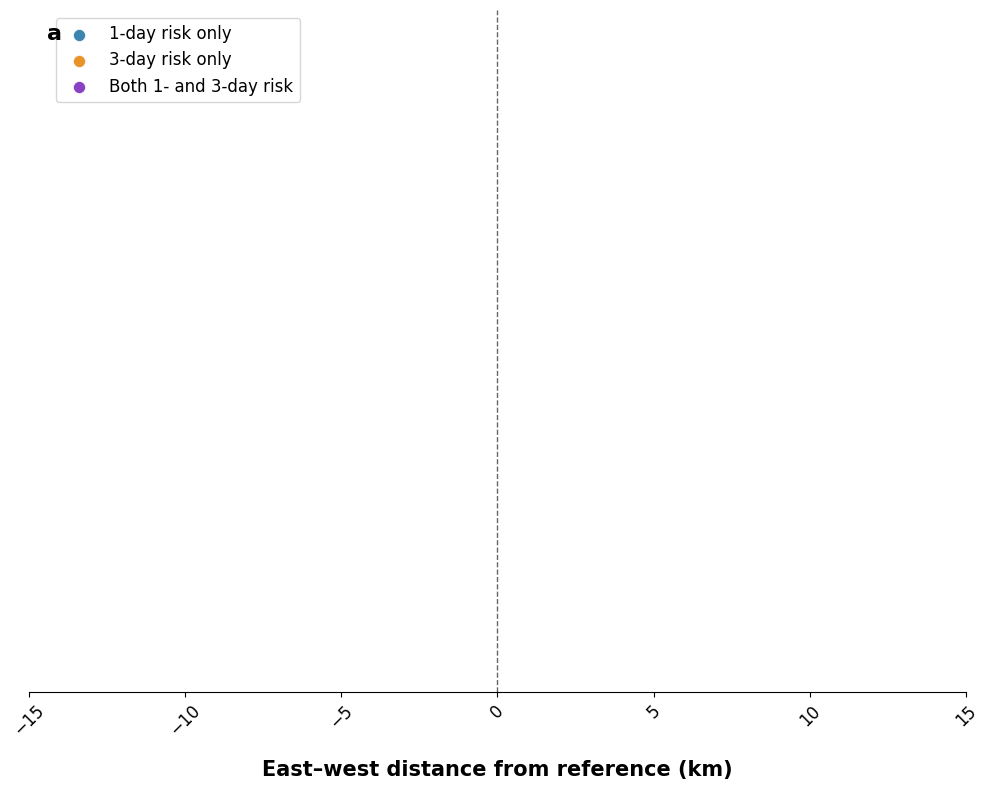

In [69]:
site_risk_plot_df = plot_site_risk_distances(
    sites_gdf,
    use_union_centroid=True,
    figsize=(10, 8),

    one_day_color='#2878A5',
    three_day_color='#E68613',
    both_color='#7B2CBF',

    point_size=75,
    point_alpha=0.9,

    legend_loc='upper left',
    legend_bbox=(0.02, 1.0),
    legend_fontsize=12,

    panel_label='a',
    xlim=(-15, 15),
    diagnostics=True,

    # save_path=PLOTS_DIR / 'site_1_3_day_risk_distances.png'
)